# Atelier Tensorflow
Contexte
Une entreprise dispose de données provenant de plusieurs bâtiments équipés de capteurs.
Pour chaque observation, on dispose par exemple de la température moyenne, de l’humidité, du
nombre d'occupants, de l’heure, du jour de la semaine, de la surface du bâtiment et de la
consommation énergétique.
L'objectif de l’atelier est de construire avec TensorFlow/Keras un réseau de neurones capable de
prédire la consommation énergétique d'un bâtiment à partir de caractéristiques telles que
température, humidité et nombre d'occupants. 

# 
2) Créer le notebook atelier_tensorflow_iot.ipynb
3) Installer et importer tensorflow, matplotlib et numpy

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Partie 1 – Génération du dataset
1) Générer aléatoirement 1000 valeurs pour chacune des variables suivantes :
a) temperature : valeurs qui suivent une loi normale avec une moyenne de 25 °C et un
écart-type de 4 °C.
b) humidite : valeurs réparties de façon uniforme entre 30 % et 80 %.
c) occupants : valeurs entières choisies entre 1 et 49 inclus.
2) Déterminer la variable consommation avec la formule suivante :
 la consommation de base (0 °C, pas d'humidité et pièce vide) est de 50
 chaque degré supplémentaire augmente la consommation de 5 unités
 chaque pourcentage d'humidité en plus ajoute 1,5 unité à la consommation
 chaque personne présente dans la pièce augmente la consommation de 4 unités
 dans la vraie vie, une formule mathématique parfaite n'existe pas. On ajoute donc une
petite variation aléatoire (moyenne de 0 et écart-type de 10) pour simuler des imprévus
ou d'autres facteurs non mesurés.
3) Rassembler les variables (temperature, humidite et occupants) dans la matrice des
caractéristiques (features) X de taille 1000x3 en convertissant éventuellement les données au
format (float32) optimisé pour les calculs
4) Créer la cible (target) y qui contiendra la variable consommation, au format float32

In [5]:

# seed : fixe le "hasard" pour que tu obtiennes toujours les mêmes valeurs
# à chaque exécution (reproductibilité), exactement comme en NumPy
np.random.seed(42)

# ===== Génération des 3 caractéristiques (X) =====

# TEMPÉRATURE : loi normale
# loc=25    -> la MOYENNE de la distribution (le centre, où les valeurs se concentrent)
# scale=4   -> l'ÉCART-TYPE (la dispersion autour de la moyenne)
# size=1000 -> combien de valeurs générer
temperature = np.random.normal(loc=25, scale=4, size=1000).round(2)

# HUMIDITÉ : loi uniforme (aucune valeur n'est "plus probable" qu'une autre)
# low=30  -> la borne minimale possible
# high=80 -> la borne maximale possible
humidite = np.random.uniform(low=30, high=80, size=1000).round(2)

# OCCUPANTS : entiers aléatoires
# randint(1, 50) : tire un entier entre 1 et 49 INCLUS
# (rappel : randint EXCLUT toujours sa borne haute, donc on met 50 pour aller jusqu'à 49)
occupants = np.random.randint(1, 50, size=1000).round(2)

# ===== Calcul de la cible (y) =====

# Bruit aléatoire : simule les petites variations imprévisibles d'une vraie mesure
# loc=0    -> centré sur 0 (le bruit peut être positif OU négatif, en moyenne nul)
# scale=10 -> dispersion du bruit autour de 0
bruit = np.random.normal(loc=0, scale=10, size=1000)

# Formule donnée par l'énoncé : consommation de base (50) + effet de chaque variable
consommation = (50 + 5 * temperature + 1.5 * humidite + 4 * occupants + bruit).round(2)

# ===== Assemblage de X et y =====

# column_stack empile les 3 tableaux CÔTE À CÔTE, comme 3 colonnes d'un tableau Excel
# résultat : une matrice de forme (1000, 3) -> 1000 lignes, 3 colonnes
# .astype("float32") : conversion demandée, format optimisé pour TensorFlow
X = np.column_stack([temperature, humidite, occupants]).astype("float32")

# y : juste la liste des 1000 valeurs de consommation, au même format
y = consommation.astype("float32")

print("Shape de X :", X.shape)   # doit afficher (1000, 3)
print("Shape de y :", y.shape)   # doit afficher (1000,)
print("Premières lignes de X :\n", X[:5])
print("Premières valeurs de y :\n", y[:5])

Shape de X : (1000, 3)
Shape de y : (1000,)
Premières lignes de X :
 [[26.99 38.37  8.  ]
 [24.45 35.23 43.  ]
 [27.59 61.82 20.  ]
 [31.09 65.32 33.  ]
 [24.06 31.58 26.  ]]
Premières valeurs de y :
 [281.64 406.7  348.62 433.62 318.93]


# Partie 2 – Découpage Train/Test
Diviser le dataset précédent (X et y) en deux ensembles distincts : un pour l'entraînement (train)
et un pour le test (test). Avec les conditions suivantes : 20% des données serviront au test ; garantir
la reproductibilité du découpage. 

In [6]:
from sklearn.model_selection import train_test_split

# X_train, X_test : caractéristiques (température, humidité, occupants)
# y_train, y_test : cible (consommation)
# test_size=0.2   -> 20% des données pour le test (demandé par l'énoncé)
# random_state=42 -> garantit la reproductibilité (demandé par l'énoncé)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Taille X_train :", X_train.shape)
print("Taille X_test  :", X_test.shape)

Taille X_train : (800, 3)
Taille X_test  : (200, 3)


# Partie 3 – Création du modèle
1) Construire un réseau de neurones qui utilise l’architecture séquentielle suivante :
a) couche 1 : 16 neurones avec relu comme fonction d’activation
b) couche 2 : 8 neurones avec relu
c) couche 3 : 1 seul neurone.
2) Afficher un résumé textuel de l'architecture du réseau de neurones. 

In [7]:
# Architecture séquentielle : les données traversent les couches dans l'ordre, une seule voie
modele = tf.keras.Sequential([
    # Couche d'entrée : chaque exemple a 3 valeurs (température, humidité, occupants)
    tf.keras.layers.Input(shape=(3,)),
    
    # Couche 1 : 16 neurones, activation relu
    # (relu transforme toute valeur négative en 0, laisse passer les valeurs positives)
    tf.keras.layers.Dense(16, activation="relu"),
    
    # Couche 2 : 8 neurones, activation relu
    tf.keras.layers.Dense(8, activation="relu"),
    
    # Couche 3 (sortie) : 1 seul neurone, PAS d'activation
    # (on prédit un nombre continu -> la consommation -> c'est une régression,
    # donc pas besoin de "sigmoid" ou "softmax" comme pour une classification)
    tf.keras.layers.Dense(1)
])

# Affiche un résumé de l'architecture : nombre de couches, de paramètres, etc.
modele.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209 (836.00 B)

 Trainable params: 209 (836.00 B)

 Non-trainable params: 0 (0.00 B)

# Partie 4 – Compilation du modèle
Compiler le modèle avec une méthode pour ajuster les poids, une fonction permettant de mesurer
l'erreur de prédiction et une métrique permettant de suivre l'erreur absolue moyenne. 

In [8]:
modele.compile(
    # optimizer : l'algorithme de descente de gradient (ajuste les poids à chaque étape)
    optimizer="adam",
    
    # loss : la fonction de perte -> mesure l'erreur entre prédiction et vraie valeur
    # "mse" (Mean Squared Error) = erreur quadratique moyenne, adaptée à la RÉGRESSION
    # (rappelle-toi : mse = moyenne des (prédiction - vraie_valeur)² -- même principe
    # que la variance qu'on a vue en NumPy)
    loss="mse",
    
    # metrics : indicateur supplémentaire à SUIVRE pendant l'entraînement,
    # sans influencer l'apprentissage lui-même
    # "mae" (Mean Absolute Error) = erreur absolue moyenne, plus facile à interpréter
    # humainement que mse (reste dans l'unité d'origine, pas au carré)
    metrics=["mae"]
)

# Partie 5 – Entraînement du modèle
1) Entrainer le modèle avec 20 % des données d'entraînement utilisés pour la validation, 50
passages sur les données et 16 observations traitées à la fois. Sauvegarder, dans la variable
history, l'historique de l’entraînement
2) Examiner le contenu de history
3) Se servir de l’historique pour visualiser (graphique) et interpréter l’apprentissage

In [9]:
# validation_split=0.2 : 20% de X_train est mis de côté PENDANT l'entraînement,
# pour vérifier que le modèle généralise bien (différent de X_test, qu'on gardera
# pour l'évaluation FINALE, après tout entraînement terminé)
# epochs=50 : 50 passages complets sur toutes les données d'entraînement
# batch_size=16 : le modèle traite 16 exemples à la fois avant d'ajuster les poids
#   (rappelle-toi : pas besoin d'attendre d'avoir vu TOUTES les données pour ajuster un peu)
history = modele.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16
)

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 148341.6875 - mae: 378.7259 - val_loss: 139174.9531 - val_mae: 367.7156
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 134767.9688 - mae: 361.2535 - val_loss: 126860.8281 - val_mae: 351.1850
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 123335.2500 - mae: 345.7612 - val_loss: 116714.0625 - val_mae: 337.0988
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 111359.1719 - mae: 328.5317 - val_loss: 99934.3516 - val_mae: 311.5465
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 85766.5547 - mae: 287.4998 - val_loss: 67757.1719 - val_mae: 256.2927
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 52741.7930 - mae: 224.2773 - val_loss: 35755.5859 - val_mae: 185.5509
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 24117.8086 - mae: 149.4975 - val_loss: 12817.0840 - val_mae: 109.2934
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7292.7197 - mae: 78.5823 - val_loss: 30

## 2) Examiner le contenu de history


In [10]:
print(history.history.keys())
print(history.history["loss"][:5])       # les 5 premières valeurs de loss (train)
print(history.history["val_loss"][:5])   # les 5 premières valeurs de loss (validation)

dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])
[148341.6875, 134767.96875, 123335.25, 111359.171875, 85766.5546875]
[139174.953125, 126860.828125, 116714.0625, 99934.3515625, 67757.171875]


## 3) Se servir de l’historique pour visualiser (graphique) et interpréter l’apprentissage

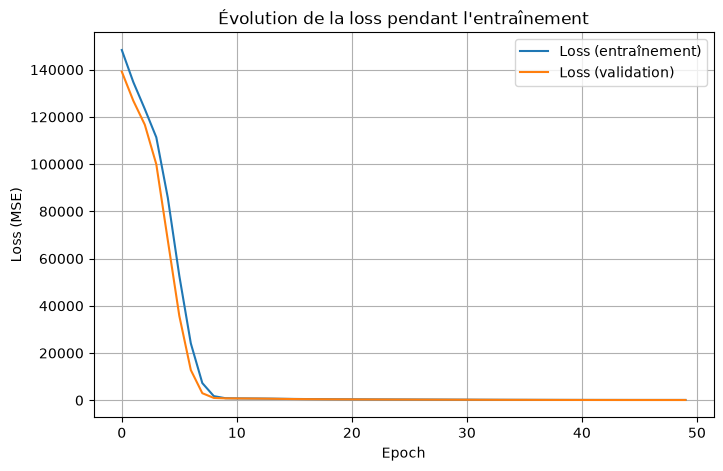

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Loss (entraînement)")
plt.plot(history.history["val_loss"], label="Loss (validation)")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Évolution de la loss pendant l'entraînement")
plt.legend()
plt.grid(True)
plt.show()

 Interprétation - Évolution de la loss

Les deux courbes (entraînement et validation) descendent rapidement et ensemble, 
de ~140000 à presque 0, en une dizaine d'epochs seulement. Elles restent très 
proches l'une de l'autre tout du long, sans que la validation ne remonte.

→ Le modèle apprend efficacement et généralise bien - il n'y a pas de signe de 
surapprentissage, puisque la performance sur les données jamais utilisées pour 
ajuster les poids (validation) suit exactement celle des données d'entraînement.

 # Partie 6 – Evaluation
1) Evaluer le modèle sur les données de test pour récupérer la fonction de perte et la métrique
cible
2) Interpréter les résultats obtenus 

## 1) Evaluer le modèle sur les données de test pour récupérer la fonction de perte et la métrique
## cible

In [12]:
# evaluate() calcule la loss et les métriques SUR X_test, sans ajuster aucun poids
resultats = modele.evaluate(X_test, y_test)

print("Résultats de l'évaluation :", resultats)
print("Loss (MSE) sur le test :", resultats[0])
print("MAE sur le test :", resultats[1])

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 179.8414 - mae: 10.8320 
Résultats de l'évaluation : [179.84136962890625, 10.831974029541016]
Loss (MSE) sur le test : 179.84136962890625
MAE sur le test : 10.831974029541016


## 2) : interprétation des résultats

La MAE de 10.83 est presque identique à l'écart-type du bruit aléatoire ajouté 
lors de la génération des données (scale=10). Cela signifie que le modèle a 
appris quasiment parfaitement la vraie formule mathématique sous-jacente 
(consommation = 50 + 5×température + 1.5×humidité + 4×occupants) - l'erreur 
restante ne vient presque plus des erreurs du modèle lui-même, mais du bruit 
aléatoire qu'on a volontairement introduit et qui, par nature, ne peut être 
ni prédit ni éliminé par aucun modèle, aussi bon soit-il.

# Partie 7 – Prédiction
1) Faire des prédictions avec les données de test
2) Comparer les prédictions avec les valeurs réelles
3) Visualiser et interpréter cette comparaison. Que devrait-on observer si le modèle était parfait ?

In [ ]:
import pandas as pd
# 1 Prédictions sur les données de test
y_pred = modele.predict(X_test)

# 2 Comparaison des 10 premières prédictions avec les vraies valeurs
comparaison = pd.DataFrame({
    "Vraie valeur": y_test[:10],
    "Prédiction": y_pred[:10].flatten()   # flatten() aplati (10,1) en (10,) pour l'affichage
})
print(comparaison)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
   Vraie valeur  Prédiction
0    334.839996  334.898346
1    383.140015  390.177277
2    377.829987  369.802338
3    292.899994  287.395386
4    396.359985  399.447388
5    367.019989  366.116638
6    309.880005  308.061920
7    293.609985  283.569519
8    360.850006  366.353333
9    414.299988  416.321411


## Comparaison des prédictions individuelles

Les prédictions sont très proches des vraies valeurs sur les 10 exemples 
observés, avec des écarts allant de moins de 1 unité (ligne 0) à environ 
10 unités (ligne 7) - cohérent avec la MAE globale de 10.83 calculée sur 
tout le jeu de test.

→ Ça confirme concrètement que le modèle a bien appris la relation entre 
température/humidité/occupants et consommation, l'écart résiduel provenant 
principalement du bruit aléatoire intrinsèque aux données, pas d'un défaut 
du modèle lui-même.

## 3) Visualiser et interpréter cette comparaison. Que devrait-on observer si le modèle était parfait ?

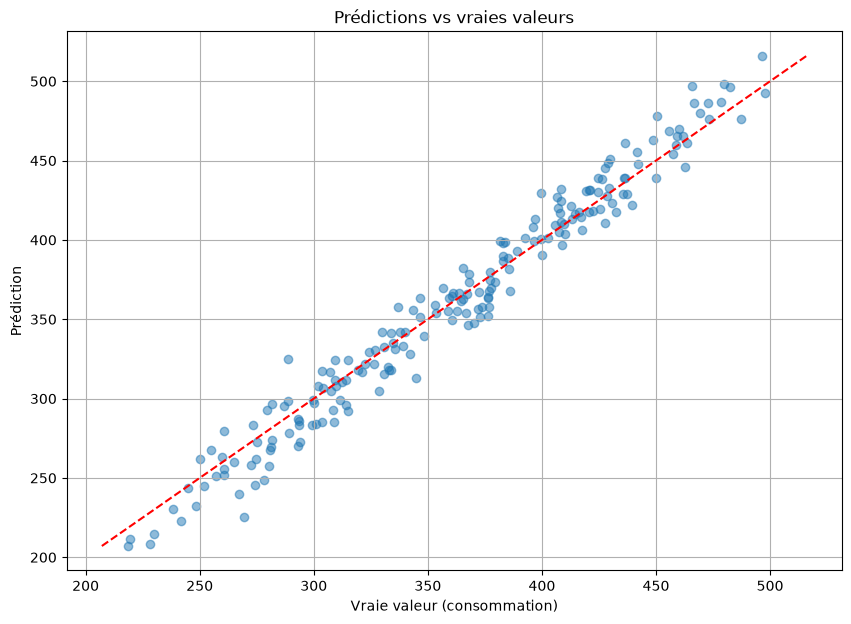

In [17]:
plt.figure(figsize=(10, 7))
plt.scatter(y_test, y_pred, alpha=0.5)

# Ligne de référence : là où prédiction = vraie valeur (la diagonale parfaite)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--")

plt.xlabel("Vraie valeur (consommation)")
plt.ylabel("Prédiction")
plt.title("Prédictions vs vraies valeurs")
plt.grid(True)
plt.show()

## Question 3 : que devrait-on observer si le modèle était parfait ?

Si le modèle était parfait, chaque point se situerait EXACTEMENT sur la ligne 
rouge en pointillés (la diagonale) - la prédiction serait toujours identique 
à la vraie valeur. En pratique, on observe un nuage de points serré autour 
de cette diagonale, avec une dispersion résiduelle due au bruit aléatoire 
qu'on a volontairement ajouté lors de la génération des données (scale=10) - 
un bruit imprévisible par nature, qu'aucun modèle, même parfait, ne pourrait 
éliminer.

# Partie 8 – Sauvegarde du modèle
Sauvegarder le modèle pour avoir models/modele_consommation.keras

In [19]:
# Sauvegarde du modèle entraîné, format .keras (le format natif recommandé)
modele.save("../models/modele_consommation.keras")

print("Modèle sauvegardé.")

Modèle sauvegardé.


# Partie 9 – Chargement du modèle
1) Charger le modèle
2) Afficher un résumé textuel du modèle chargé
3) Effectuer une nouvelle prédiction 

In [20]:
# 1) Chargement du modèle sauvegardé
modele_charge = tf.keras.models.load_model("../models/modele_consommation.keras")



In [21]:
# 2) Résumé de l'architecture, pour vérifier qu'elle correspond bien à l'originale
modele_charge.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 629 (2.46 KB)

 Trainable params: 209 (836.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 420 (1.64 KB)

In [22]:
# 3) Nouvelle prédiction, pour vérifier que le modèle rechargé fonctionne bien
nouvelle_prediction = modele_charge.predict(X_test[:5])
print("Prédictions du modèle rechargé :", nouvelle_prediction.flatten())
print("Prédictions du modèle original  :", y_pred[:5].flatten())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Prédictions du modèle rechargé : [334.89835 390.17728 369.80234 287.3954  399.4474 ]
Prédictions du modèle original  : [334.89835 390.17728 369.80234 287.3954  399.4474 ]


# Partie 10 : Fonction d'inférence
1) Avec le modèle chargé, définir une fonction predire_consommation()
2) Tester la fonction 

## 1) Avec le modèle chargé, définir une fonction predire_consommation()


In [24]:
def predire_consommation(temperature, humidite, occupants, modele=modele_charge):
    """
    Prédit la consommation énergétique à partir de température, humidité et occupants,
    en utilisant le modèle TensorFlow déjà entraîné et rechargé.
    """
    # On assemble les 3 valeurs dans la MÊME forme que X pendant l'entraînement :
    # une matrice (1, 3) -> 1 seul exemple, 3 caractéristiques
    nouvelle_donnee = np.array([[temperature, humidite, occupants]], dtype="float32")
    
    # Prédiction (verbose=0 pour ne pas afficher la barre de progression)
    prediction = modele.predict(nouvelle_donnee, verbose=0)
    
    # On extrait la valeur unique du résultat (qui est de forme (1,1))
    return prediction[0][0]



## 2) Tester la fonction 

In [25]:
# Test de la fonction
resultat = predire_consommation(temperature=26, humidite=55, occupants=10)
print(f"Consommation prédite : {resultat:.2f}")

Consommation prédite : 299.19


In [26]:
# Vérification manuelle avec la vraie formule (sans le bruit, impossible à deviner)
verif = 50 + 5*26 + 1.5*55 + 4*10
print(f"Calcul théorique (sans bruit) : {verif:.2f}")
print(f"Prédiction du modèle          : {resultat:.2f}")

Calcul théorique (sans bruit) : 302.50
Prédiction du modèle          : 299.19
